# 05. Average Treatment Effects: ATE, ATT, ATC, and CATE

Potential outcomes define causal effects at the unit level: $\tau_i = Y_i(1) - Y_i(0)$. But individual causal effects are usually unobserved because each unit reveals only one potential outcome.

Applied causal inference therefore often focuses on **average** treatment effects. The word "average" sounds simple, but it hides a crucial question:

> Average over whom?

The answer changes the estimand, the business interpretation, and often the decision.

This lecture introduces the most common average treatment-effect targets:

- **ATE**: average treatment effect for the full target population;
- **ATT**: average treatment effect for units that were actually treated;
- **ATC**: average treatment effect for units that were actually untreated;
- **CATE**: conditional average treatment effect for units with particular features.

We will use a retention-offer example where the same intervention has a positive ATE, a much larger ATT, a smaller ATC, and strong heterogeneity by price sensitivity. The goal is to make the estimands feel operational, not just symbolic.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Define ATE, ATT, ATC, CATE, and grouped average treatment effects.
2. Explain why ATE, ATT, and ATC can be different.
3. Connect each estimand to a business decision.
4. Show why the observed treated-minus-control difference is not generally an average treatment effect.
5. Use a randomized experiment to estimate the ATE and quantify uncertainty.
6. Interpret heterogeneity and distinguish risk targeting from effect targeting.
7. Explain why a single average effect can hide important segment-level variation.


## 1. The Estimands

For a binary treatment, let $Y_i(1)$ be unit $i$'s potential outcome under treatment and $Y_i(0)$ be the potential outcome under control. The individual treatment effect is:

$$
\tau_i = Y_i(1) - Y_i(0)
$$

The **average treatment effect** for the full target population is:

$$
ATE = E[Y(1) - Y(0)]
$$

The **average treatment effect on the treated** is:

$$
ATT = E[Y(1) - Y(0) \mid A = 1]
$$

The **average treatment effect on the controls** is:

$$
ATC = E[Y(1) - Y(0) \mid A = 0]
$$

The **conditional average treatment effect** is:

$$
CATE(x) = E[Y(1) - Y(0) \mid X = x]
$$

These are all averages of the same unit-level causal effect, but over different groups. Rubin (1974) formalized causal effects using potential outcomes in randomized and nonrandomized studies. Rosenbaum and Rubin (1983) discuss average treatment effects in observational adjustment, and later work such as Athey and Imbens (2016) and Wager and Athey (2018) focuses on heterogeneity and conditional effects.


In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 115)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def estimand_summary_table():
    """Build a compact reference table for ATE, ATT, ATC, and CATE estimands.

    Returns:
        pandas.DataFrame: Reference table describing the estimand family.
    """
    return pd.DataFrame(
        [
            {
                "estimand": "ATE",
                "definition": "E[Y(1) - Y(0)]",
                "plain_language": "Average effect if everyone in the target population were treated instead of untreated.",
                "business_question": "Should we launch this intervention broadly?",
            },
            {
                "estimand": "ATT",
                "definition": "E[Y(1) - Y(0) | A = 1]",
                "plain_language": "Average effect for the units that actually received treatment.",
                "business_question": "How much value did the current program create for participants?",
            },
            {
                "estimand": "ATC",
                "definition": "E[Y(1) - Y(0) | A = 0]",
                "plain_language": "Average effect for the units that did not receive treatment.",
                "business_question": "What might happen if we expanded treatment to untreated units?",
            },
            {
                "estimand": "CATE",
                "definition": "E[Y(1) - Y(0) | X = x]",
                "plain_language": "Average effect for units with a particular feature profile or segment.",
                "business_question": "Who benefits most, and should we target the intervention?",
            },
        ]
    )

estimand_summary_table()

,estimand,definition,plain_language,business_question
0,ATE,E[Y(1) - Y(0)],Average effect if everyone in the target population were treated instead of untreated.,Should we launch this intervention broadly?
1,ATT,E[Y(1) - Y(0) | A = 1],Average effect for the units that actually received treatment.,How much value did the current program create for participants?
2,ATC,E[Y(1) - Y(0) | A = 0],Average effect for the units that did not receive treatment.,What might happen if we expanded treatment to untreated units?
3,CATE,E[Y(1) - Y(0) | X = x],Average effect for units with a particular feature profile or segment.,"Who benefits most, and should we target the intervention?"


The estimand should match the decision.

If the question is whether a program should have been offered to the people who received it, ATT is often natural. If the question is whether to expand a program to people who did not receive it, ATC is closer to the decision. If the question is whether to launch for everyone, ATE is natural. If capacity is limited, CATE or grouped effects become important because targeting can matter more than the overall average.

## 2. A Synthetic Retention-Offer Dataset

We will simulate a subscription business deciding whether to send a proactive retention offer.

The unit is an active subscriber. The treatment is a retention offer. The outcome is 60-day net value per subscriber after accounting for margin, churn risk, and offer cost. Higher is better.

The business historically targeted offers to subscribers with higher churn risk and higher price sensitivity. Those customers are more likely to benefit from the offer, but they also have lower baseline value without the offer. This creates the same pattern we often see in real data:

- the treated group looks worse in observed outcomes;
- the intervention is still beneficial on average;
- the effect varies substantially across customers.


**Dataset and experiment setup.** The units are customers who may receive a retention offer. The simulation includes baseline churn risk, account value, treatment assignment, potential outcomes, and heterogeneous treatment effects. The treatment effect is larger for some customers than others, which is important because ATE, ATT, ATC, and CATE answer different decision questions. This dataset is intentionally closer to a retention targeting problem than a clean classroom coin flip. It lets us ask whether we care about the average customer, the customers actually treated, the untreated customers who could be targeted next, or high-value subgroups under a budget constraint.

In [3]:
# Build the summary table used to connect the calculation back to the design question.
rng = np.random.default_rng(505)
n_customers = 20_000

engagement = rng.normal(loc=0, scale=1, size=n_customers)
tenure_months = np.clip(rng.gamma(shape=3, scale=7, size=n_customers), 1, 72)
price_sensitivity = np.clip(
    rng.beta(a=2.4, b=2.7, size=n_customers)
    + 0.12 * (-engagement)
    - 0.002 * tenure_months,
    0,
    1,
)
competitor_contact = rng.binomial(
    n=1,
    p=expit(-1.0 + 1.5 * price_sensitivity - 0.45 * engagement),
)
monthly_margin = np.exp(
    3.1
    + 0.22 * engagement
    + 0.006 * tenure_months
    + rng.normal(loc=0, scale=0.28, size=n_customers)
)
baseline_churn_risk = expit(
    -1.7
    - 0.75 * engagement
    - 0.015 * tenure_months
    + 1.05 * price_sensitivity
    + 0.90 * competitor_contact
)

# Potential outcome under no offer: 60-day net value.
y0_no_offer = monthly_margin * 2 * (1 - baseline_churn_risk) + rng.normal(loc=0, scale=8, size=n_customers)

# Heterogeneous treatment effect: the offer helps price-sensitive, at-risk customers more,
# but can cannibalize value for highly engaged customers who were unlikely to churn.
true_tau = (
    -3.5
    + 18 * price_sensitivity
    + 6 * competitor_contact
    + 5 * baseline_churn_risk
    - 4 * np.maximum(engagement, 0)
    + rng.normal(loc=0, scale=4, size=n_customers)
)
true_tau = np.clip(true_tau, -15, 35)
y1_offer = y0_no_offer + true_tau

# Historical targeting: offers are more likely among high-risk and price-sensitive customers.
offer_probability = expit(
    -1.5
    + 2.4 * baseline_churn_risk
    + 1.3 * price_sensitivity
    + 0.8 * competitor_contact
    - 0.3 * engagement
)
offer = rng.binomial(n=1, p=offer_probability)

observed_net_value = np.where(offer == 1, y1_offer, y0_no_offer)

customers = pd.DataFrame(
    {
        "engagement": engagement,
        "tenure_months": tenure_months,
        "price_sensitivity": price_sensitivity,
        "competitor_contact": competitor_contact,
        "monthly_margin": monthly_margin,
        "baseline_churn_risk": baseline_churn_risk,
        "offer": offer,
        "net_value_60d": observed_net_value,
        # Simulation-only potential outcomes.
        "_Y0_no_offer": y0_no_offer,
        "_Y1_offer": y1_offer,
        "_tau": true_tau,
    }
)

customers.head()


,engagement,tenure_months,price_sensitivity,competitor_contact,monthly_margin,baseline_churn_risk,offer,net_value_60d,_Y0_no_offer,_Y1_offer,_tau
0,1.272,39.655,0.437,0,24.675,0.058,0,32.159,32.159,36.032,3.874
1,-1.252,36.785,0.194,0,18.786,0.248,1,24.879,28.573,24.879,-3.695
2,0.422,72.000,0.057,0,50.905,0.046,0,90.584,90.584,89.570,-1.013
3,-1.628,9.313,0.775,1,25.108,0.749,1,35.696,15.747,35.696,19.949
4,-0.239,21.779,0.778,1,21.409,0.467,1,52.693,33.245,52.693,19.448


In A Synthetic Retention-Offer Dataset, the table keeps the counterfactual gap in view. Each unit gives us one realized outcome; the estimand asks about two possible choices.

In [4]:
# Assemble the A Synthetic Retention-Offer Dataset summary table used for interpretation.
observed_summary = (
    customers.groupby("offer")
    .agg(
        n=("net_value_60d", "size"),
        observed_net_value=("net_value_60d", "mean"),
        baseline_churn_risk=("baseline_churn_risk", "mean"),
        price_sensitivity=("price_sensitivity", "mean"),
        competitor_contact=("competitor_contact", "mean"),
        engagement=("engagement", "mean"),
        baseline_Y0=("_Y0_no_offer", "mean"),
        true_tau=("_tau", "mean"),
    )
    .rename(index={0: "No offer", 1: "Offer"})
)

smart_display(observed_summary)


,n,observed_net_value,baseline_churn_risk,price_sensitivity,competitor_contact,engagement,baseline_Y0,true_tau
offer,,,,,,,,
No offer,9914,48.761,0.188,0.352,0.249,0.388,48.761,2.977
Offer,10086,42.790,0.371,0.508,0.587,-0.378,32.613,10.177


The offer group has lower observed 60-day net value than the no-offer group. A naive dashboard might say the offer is bad.

But the offer group also has higher baseline churn risk, higher price sensitivity, and lower baseline potential outcome under no offer. The offer was targeted toward customers who were already harder to retain.

Observed treated-minus-control differences need a design argument before they can be read as causal effects. We need to specify which average of $Y(1) - Y(0)$ we care about.

## 3. Computing ATE, ATT, and ATC in the Simulation

Because this is a simulation, both potential outcomes are available. We can compute the true estimands directly.

In real data, these quantities are targets, not directly observable facts.


In [5]:
# Build the summary table used to connect the calculation back to the design question.
ate = customers["_tau"].mean()
att = customers.loc[customers["offer"] == 1, "_tau"].mean()
atc = customers.loc[customers["offer"] == 0, "_tau"].mean()
observed_difference = (
    customers.loc[customers["offer"] == 1, "net_value_60d"].mean()
    - customers.loc[customers["offer"] == 0, "net_value_60d"].mean()
)

estimands = pd.DataFrame(
    {
        "quantity": [
            "ATE: average over all active subscribers",
            "ATT: average over subscribers who received the offer",
            "ATC: average over subscribers who did not receive the offer",
            "Observed difference: offer minus no offer",
        ],
        "value_dollars_per_subscriber": [ate, att, atc, observed_difference],
    }
)

smart_display(estimands)


,quantity,value_dollars_per_subscriber
0,ATE: average over all active subscribers,6.608
1,ATT: average over subscribers who received the offer,10.177
2,ATC: average over subscribers who did not receive the offer,2.977
3,Observed difference: offer minus no offer,-5.971


In Computing ATE, ATT, and ATC in the Simulation, the table keeps the counterfactual gap in view. The table is useful because it separates observed outcomes from the counterfactual comparison we actually want.

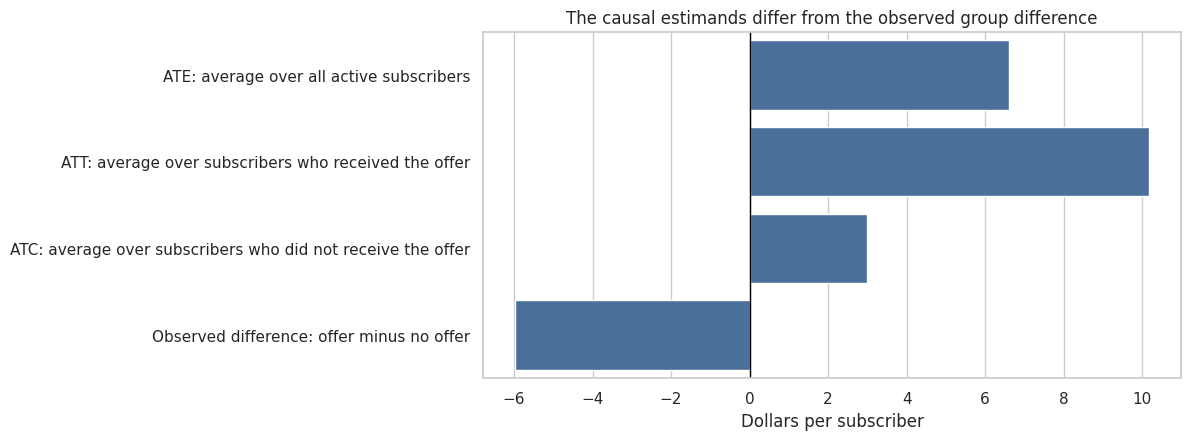

In [6]:
# Build the Computing ATE, ATT, and ATC in the Simulation plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_estimands = estimands.copy()
sns.barplot(
    data=plot_estimands,
    x="value_dollars_per_subscriber",
    y="quantity",
    color="#3b6ea8",
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("The causal estimands differ from the observed group difference")
ax.set_xlabel("Dollars per subscriber")
ax.set_ylabel("")
plt.show()


The ATE is positive: if everyone in the target population received the offer instead of no offer, average 60-day net value would increase.

The ATT is larger than the ATE because the historical targeting process selected customers who were more responsive to the offer. The ATC is smaller because untreated customers include many subscribers who were less likely to benefit.

The observed treated-minus-control difference is negative because the treated customers had much lower baseline potential outcomes. It is not an estimate of the ATE, ATT, or ATC without additional assumptions and adjustment.

## 4. ATE as a Weighted Average of Group Effects

The ATE can be written as a weighted average of subgroup effects. If $G$ is a group label, then:

$$
ATE = \sum_g P(G=g) E[Y(1) - Y(0) \mid G=g]
$$

This identity is simple but important. A single average effect can hide large positive and negative effects across groups.


In [7]:
# Build the summary table used to connect the calculation back to the design question.
customers["price_sensitivity_quartile"] = pd.qcut(
    customers["price_sensitivity"],
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
)

quartile_effects = (
    customers.groupby("price_sensitivity_quartile", observed=True)
    .agg(
        n=("_tau", "size"),
        share=("_tau", lambda x: len(x) / len(customers)),
        cate=("_tau", "mean"),
        baseline_churn_risk=("baseline_churn_risk", "mean"),
        observed_offer_rate=("offer", "mean"),
    )
    .reset_index()
)
quartile_effects["weighted_contribution_to_ATE"] = quartile_effects["share"] * quartile_effects["cate"]
smart_display(quartile_effects)


,price_sensitivity_quartile,n,share,cate,baseline_churn_risk,observed_offer_rate,weighted_contribution_to_ATE
0,Q1 lowest,5000,0.25,-1.838,0.132,0.292,-0.460
1,Q2,5000,0.25,4.390,0.227,0.443,1.097
2,Q3,5000,0.25,8.820,0.308,0.560,2.205
3,Q4 highest,5000,0.25,15.061,0.454,0.722,3.765


In ATE as a Weighted Average of Group Effects, the table keeps the counterfactual gap in view. The observed row is only one path for the unit. The causal question compares that path with the one we did not see.

In [8]:
# Assemble the ATE as a Weighted Average of Group Effects summary table used for interpretation.
weighted_ate_from_quartiles = quartile_effects["weighted_contribution_to_ATE"].sum()

pd.DataFrame(
    {
        "quantity": ["ATE computed directly", "ATE reconstructed from quartile effects"],
        "value": [ate, weighted_ate_from_quartiles],
    }
)


,quantity,value
0,ATE computed directly,6.608
1,ATE reconstructed from quartile effects,6.608


In ATE as a Weighted Average of Group Effects, the table keeps the counterfactual gap in view. This is the missing-outcome problem in miniature: one observed result, two potential worlds.

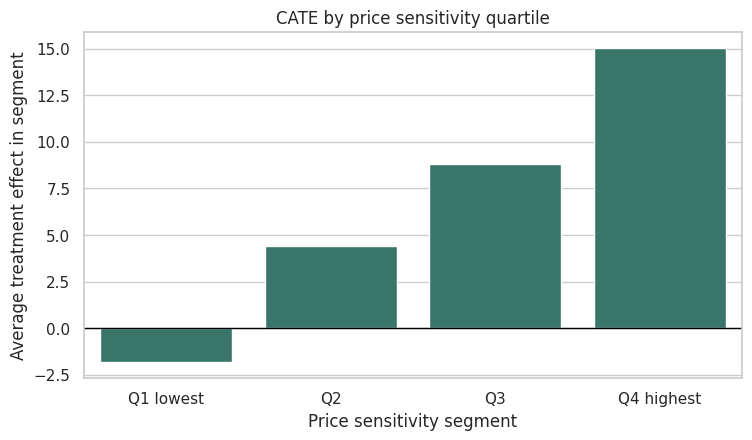

In [9]:
# Build the ATE as a Weighted Average of Group Effects plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.barplot(
    data=quartile_effects,
    x="price_sensitivity_quartile",
    y="cate",
    color="#2f7f6f",
    ax=ax,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("CATE by price sensitivity quartile")
ax.set_xlabel("Price sensitivity segment")
ax.set_ylabel("Average treatment effect in segment")
plt.show()


The lowest price-sensitivity quartile has a negative average effect. These subscribers are less moved by the offer, so the discount often cannibalizes value.

The highest price-sensitivity quartile has a large positive average effect. These subscribers are more likely to respond to the offer and more likely to be at risk without it.

The ATE is the weighted average of these segment-level effects. It is useful for broad launch decisions, but it can be too blunt for targeting decisions.

## 5. CATE, GATE, and Heterogeneity

The CATE is defined for a feature profile $X=x$:

$$
CATE(x) = E[Y(1) - Y(0) \mid X=x]
$$

In practice, exact feature profiles can be too granular. Analysts often estimate **grouped average treatment effects**, sometimes called GATEs:

$$
GATE_g = E[Y(1) - Y(0) \mid G=g]
$$

where $G$ is a segment such as price-sensitivity quartile, customer tenure band, market, device type, or risk tier.


In [10]:
# Build the summary table used to connect the calculation back to the design question.
customers["risk_tier"] = pd.qcut(
    customers["baseline_churn_risk"],
    q=4,
    labels=["Risk Q1 lowest", "Risk Q2", "Risk Q3", "Risk Q4 highest"],
)

risk_effects = (
    customers.groupby("risk_tier", observed=True)
    .agg(
        n=("_tau", "size"),
        cate=("_tau", "mean"),
        price_sensitivity=("price_sensitivity", "mean"),
        offer_rate=("offer", "mean"),
        baseline_Y0=("_Y0_no_offer", "mean"),
    )
    .reset_index()
)

smart_display(risk_effects)


,risk_tier,n,cate,price_sensitivity,offer_rate,baseline_Y0
0,Risk Q1 lowest,5000,-3.191,0.233,0.212,64.238
1,Risk Q2,5000,4.215,0.379,0.387,46.419
2,Risk Q3,5000,9.544,0.480,0.594,33.803
3,Risk Q4 highest,5000,15.864,0.629,0.824,18.009


In CATE, GATE, and Heterogeneity, the table keeps the counterfactual gap in view. Each unit gives us one realized outcome; the estimand asks about two possible choices.

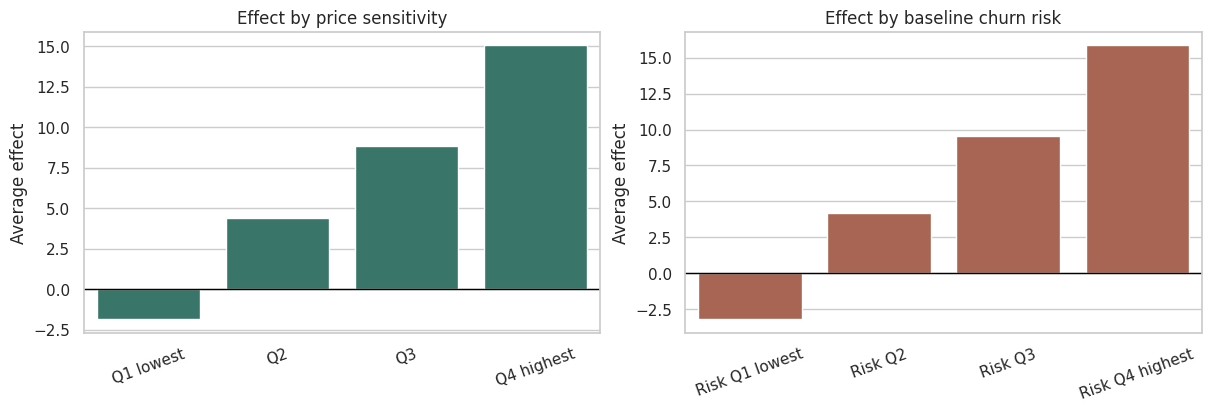

In [11]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.barplot(
    data=quartile_effects,
    x="price_sensitivity_quartile",
    y="cate",
    color="#2f7f6f",
    ax=axes[0],
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Effect by price sensitivity")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average effect")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=risk_effects,
    x="risk_tier",
    y="cate",
    color="#b75d45",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Effect by baseline churn risk")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average effect")
axes[1].tick_params(axis="x", rotation=20)

plt.show()


Both segmentations reveal heterogeneity, but they describe different structure. Price sensitivity is directly related to response to the offer. Baseline churn risk also helps, while risk differs from treatment effect.

This distinction is central to uplift modeling and policy learning. A high-risk customer may or may not be a high-response customer, and a low-risk customer may or may not be a low-response customer. The treatment effect is the change induced by the action, not the level of the outcome under business as usual.

## 6. Estimating ATE in a Randomized Experiment

So far we used simulation-only potential outcomes. In a real randomized experiment, we observe only one outcome per unit, but random assignment makes the treated and control groups comparable on average.

For a completely randomized experiment, the simple difference in means estimates the ATE:

$$
\hat{\tau}_{ATE} = \bar{Y}_{A=1} - \bar{Y}_{A=0}
$$

A common standard error is:

$$
SE(\hat{\tau}) = \sqrt{\frac{s_1^2}{n_1} + \frac{s_0^2}{n_0}}
$$

where $s_1^2$ and $s_0^2$ are the sample variances in the treated and control groups.


In [12]:
# Build the summary table used to connect the calculation back to the design question.
rng_experiment = np.random.default_rng(909)
experiment = customers.copy()
experiment["random_offer"] = rng_experiment.binomial(n=1, p=0.5, size=len(experiment))
experiment["experimental_outcome"] = np.where(
    experiment["random_offer"] == 1,
    experiment["_Y1_offer"],
    experiment["_Y0_no_offer"],
)

y_treated = experiment.loc[experiment["random_offer"] == 1, "experimental_outcome"]
y_control = experiment.loc[experiment["random_offer"] == 0, "experimental_outcome"]

experiment_ate_hat = y_treated.mean() - y_control.mean()
experiment_se = np.sqrt(y_treated.var(ddof=1) / len(y_treated) + y_control.var(ddof=1) / len(y_control))
ci_low = experiment_ate_hat - 1.96 * experiment_se
ci_high = experiment_ate_hat + 1.96 * experiment_se

pd.DataFrame(
    {
        "quantity": [
            "True ATE in the finite population",
            "Experimental difference in means",
            "Standard error",
            "95% CI lower bound",
            "95% CI upper bound",
        ],
        "value": [ate, experiment_ate_hat, experiment_se, ci_low, ci_high],
    }
)


,quantity,value
0,True ATE in the finite population,6.608
1,Experimental difference in means,6.603
2,Standard error,0.310
3,95% CI lower bound,5.995
4,95% CI upper bound,7.211


The randomized estimate is close to the true ATE and its uncertainty interval covers the true value in this run.

Randomization did not reveal individual effects. It made the treated and control groups comparable enough that the average difference in observed outcomes estimates the average difference in potential outcomes.

In [13]:
# Build the summary table used to connect the calculation back to the design question.
rng_repeated = np.random.default_rng(910)
n_repeated_experiments = 1_000
repeated_estimates = []

for _ in range(n_repeated_experiments):
    z = rng_repeated.binomial(n=1, p=0.5, size=len(customers))
    y_obs = np.where(z == 1, customers["_Y1_offer"], customers["_Y0_no_offer"])
    repeated_estimates.append(y_obs[z == 1].mean() - y_obs[z == 0].mean())

repeated_estimates = np.array(repeated_estimates)

pd.DataFrame(
    {
        "quantity": [
            "True ATE",
            "Mean estimate over repeated randomized experiments",
            "Standard deviation of estimates",
            "2.5th percentile",
            "97.5th percentile",
        ],
        "value": [
            ate,
            repeated_estimates.mean(),
            repeated_estimates.std(),
            np.percentile(repeated_estimates, 2.5),
            np.percentile(repeated_estimates, 97.5),
        ],
    }
)


,quantity,value
0,True ATE,6.608
1,Mean estimate over repeated randomized experiments,6.611
2,Standard deviation of estimates,0.308
3,2.5th percentile,6.015
4,97.5th percentile,7.235


In Estimating ATE in a Randomized Experiment, the table keeps the counterfactual gap in view. The table is useful because it separates observed outcomes from the counterfactual comparison we actually want.

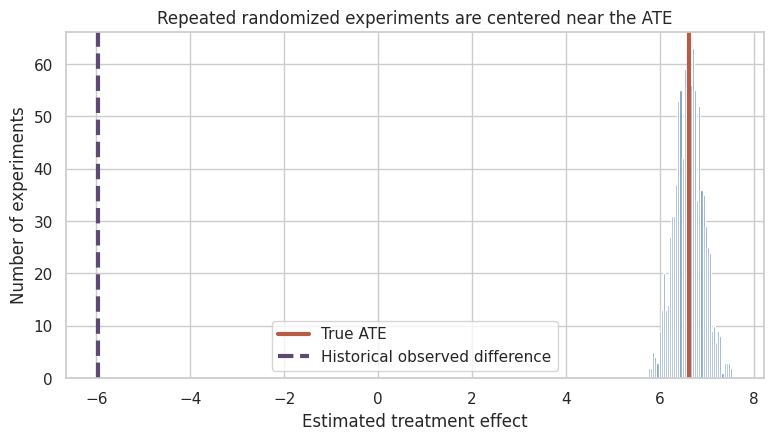

In [14]:
# Build the Discussion plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(repeated_estimates, bins=40, color="#3b6ea8", alpha=0.75, ax=ax)
ax.axvline(ate, color="#b75d45", linewidth=3, label="True ATE")
ax.axvline(observed_difference, color="#5c4a72", linewidth=3, linestyle="--", label="Historical observed difference")
ax.set_title("Repeated randomized experiments are centered near the ATE")
ax.set_xlabel("Estimated treatment effect")
ax.set_ylabel("Number of experiments")
ax.legend()
plt.show()


The repeated randomized estimates are centered near the true ATE. The historical observed difference is far away because historical offer assignment was targeted rather than randomized.

This is a crucial lesson: the same numerical estimator, treated mean minus control mean, behaves very differently depending on the assignment mechanism.

## 7. Targeting Under a Budget Constraint

Suppose the company can send offers to only 30% of subscribers because of budget, operations, or brand constraints.

Compare four policies:

1. random targeting;
2. targeting the highest baseline churn risk;
3. targeting the largest true treatment effects, an oracle benchmark;
4. offering to everyone, if no budget constraint existed.

The oracle benchmark is not available in real life because true treatment effects are not observed. It helps us understand what a treatment-effect targeting system is trying to approximate.


In [15]:
# Build the summary table used to connect the calculation back to the design question.
budget_fraction = 0.30
budget = int(budget_fraction * len(customers))

base_value = customers["_Y0_no_offer"].mean()
benefit = customers["_tau"].to_numpy()
risk = customers["baseline_churn_risk"].to_numpy()

random_indices = rng.choice(len(customers), size=budget, replace=False)
risk_indices = np.argsort(risk)[-budget:]
oracle_indices = np.argsort(benefit)[-budget:]
all_indices = np.arange(len(customers))

policies = {
    "Random 30%": random_indices,
    "Highest-risk 30%": risk_indices,
    "Largest-effect 30% oracle": oracle_indices,
    "Offer everyone": all_indices,
}

policy_rows = []
for policy_name, indices in policies.items():
    assigned = np.zeros(len(customers), dtype=bool)
    assigned[indices] = True
    value = np.where(assigned, customers["_Y1_offer"], customers["_Y0_no_offer"]).mean()
    policy_rows.append(
        {
            "policy": policy_name,
            "offer_rate": assigned.mean(),
            "mean_effect_among_targeted": customers.loc[assigned, "_tau"].mean(),
            "incremental_value_vs_no_offers": value - base_value,
        }
    )

policy_results = pd.DataFrame(policy_rows)
smart_display(policy_results)


,policy,offer_rate,mean_effect_among_targeted,incremental_value_vs_no_offers
0,Random 30%,0.3,6.505,1.952
1,Highest-risk 30%,0.3,15.195,4.559
2,Largest-effect 30% oracle,0.3,17.009,5.103
3,Offer everyone,1.0,6.608,6.608


In Targeting Under a Budget Constraint, the table keeps the counterfactual gap in view. The observed row is only one path for the unit. The causal question compares that path with the one we did not see.

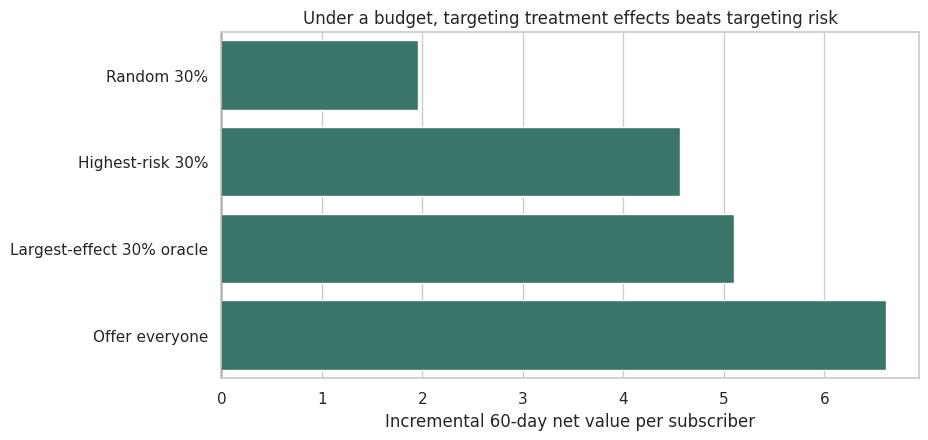

In [16]:
# Build the Targeting Under a Budget Constraint plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.5))
ordered = policy_results.sort_values("incremental_value_vs_no_offers")
sns.barplot(
    data=ordered,
    x="incremental_value_vs_no_offers",
    y="policy",
    color="#2f7f6f",
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Under a budget, targeting treatment effects beats targeting risk")
ax.set_xlabel("Incremental 60-day net value per subscriber")
ax.set_ylabel("")
plt.show()


Risk targeting performs well because high-risk subscribers have more value at stake. But the oracle effect-targeting policy performs better because it targets subscribers whose outcomes are most changed by the offer.

The difference between risk and effect is one of the most important practical lessons in causal machine learning:

- risk model: who is likely to churn?
- effect model: whose churn-related value changes if we intervene?
- policy model: whom should we treat given cost, capacity, and guardrails?

Average effects tell us whether an intervention is promising. Heterogeneous effects tell us where it is most useful.

## 8. What Each Estimand Means for the Retention Team

The estimands answer different questions:

| Estimand | Retention interpretation |
|---|---|
| ATE | Expected value if the offer were assigned broadly to the whole eligible population. |
| ATT | Value created for the customers historically selected by the current targeting policy. |
| ATC | Expected value if the offer were expanded to customers not currently selected. |
| CATE / GATE | Expected value for a customer profile or segment, useful for targeting. |

This is why stakeholder alignment matters. A marketing lead may ask, "Did the program work for the people we sent it to?" That is close to ATT. A product lead may ask, "Should every eligible customer see this offer?" That is close to ATE. A growth lead may ask, "Where should we expand next?" That is close to ATC and CATE.


| decision | natural_estimand | why |
|---|---|---|
| Evaluate current campaign performance | ATT | The treated group is the group that actually received the offer. |
| Launch offer to all eligible subscribers | ATE | The broad-launch policy applies to the full target population. |
| Expand offer to currently untreated subscribers | ATC | Expansion affects customers who did not receive the offer under current policy. |
| Target under a limited budget | CATE / GATE / policy value | The best target group depends on effect heterogeneity and intervention cost. |
| Monitor fairness or customer harm | Subgroup effects and guardrail effects | A positive average can hide harm or weak effects for specific groups. |


## 9. Common Mistakes

1. **Calling the observed group difference an ATE.** It is only an ATE estimator under a credible design or identification assumptions.
2. **Reporting only ATE when the decision is targeting.** Averages can hide valuable heterogeneity.
3. **Using ATT to justify broad expansion.** The current treated group may be more responsive than the expansion group.
4. **Using ATC to evaluate the current program.** The untreated group may differ from the treated group in ways that matter.
5. **Equating risk with treatment effect.** High-risk customers may not be movable by the intervention.
6. **Searching many subgroups and reporting the best one without honesty.** Heterogeneity analysis can overfit. Later notebooks will cover validation and honest sample splitting.
7. **Forgetting cost and guardrails.** A positive effect on one metric may not imply positive business value.


## 10. Key Takeaways

1. ATE, ATT, ATC, and CATE are different averages of $Y(1) - Y(0)$.
2. The right estimand depends on the decision: broad launch, current-program evaluation, expansion, or targeting.
3. Observed treated-minus-control differences require a design argument before they can be read as causal effects.
4. ATT can be larger than ATE when treatment is targeted toward high-response units.
5. ATC can be smaller than ATT when untreated units are less responsive.
6. CATE and grouped effects reveal heterogeneity that a single ATE can hide.
7. Randomized experiments make simple differences in means credible for ATE estimation, with uncertainty quantification.
8. Under budget constraints, targeting by treatment effect can outperform targeting by risk.

## Preview of the Next Lecture

The next lecture introduces the core identification assumptions: consistency, exchangeability, positivity, and SUTVA. These assumptions explain when observed data can identify the causal estimands defined in this lecture.


## References

- Athey, S., & Imbens, G. W. (2016). Recursive partitioning for heterogeneous causal effects. *Proceedings of the National Academy of Sciences, 113*(27), 7353-7360. https://doi.org/10.1073/pnas.1510489113. Access: open / DOI page.
- Lee, K., Bargagli-Stoffi, F. J., & Dominici, F. (2020). Causal rule ensemble: Interpretable discovery and inference of heterogeneous treatment effects. *arXiv*. https://doi.org/10.48550/arxiv.2009.09036. Access: open / DOI page.
- Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika, 70*(1), 41-55. https://doi.org/10.1093/biomet/70.1.41. Access: open / DOI page.
- Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. *Journal of Educational Psychology, 66*(5), 688-701. https://doi.org/10.1037/h0037350. Access: publisher / DOI page.
- Wager, S., & Athey, S. (2018). Estimation and inference of heterogeneous treatment effects using random forests. *Journal of the American Statistical Association, 113*(523), 1228-1242. https://doi.org/10.1080/01621459.2017.1319839. Access: publisher / DOI page.
